# Estudo de Machine Learning - Falencia de Empresas

## Etapa 1: Importacao e carregamento dos dados

Nesta etapa, vamos importar as bibliotecas principais e carregar o arquivo `archive/data.csv` em um DataFrame.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:.4f}'.format

df = pd.read_csv('archive/data.csv')

print('Arquivo carregado com sucesso.')

Arquivo carregado com sucesso.


## Etapa 2: Inspecao inicial da base

Nesta etapa, vamos visualizar as primeiras linhas do conjunto de dados, verificar seu tamanho, listar colunas e tipos, e identificar a variavel target.

In [47]:
print('Primeiras linhas da base:')
display(df.head())

print('Shape da base:', df.shape)

print('\nLista de colunas:')
for coluna in df.columns:
    print('-', coluna)

print('\nTipos de dados:')
display(df.dtypes.to_frame(name='tipo_dado'))

print('\nColunas textuais ou categoricas com baixa cardinalidade:')
colunas_textuais_categoricas = df.select_dtypes(include=['object', 'category']).columns
if len(colunas_textuais_categoricas) == 0:
    print('Nenhuma coluna object/category encontrada.')
else:
    for coluna in colunas_textuais_categoricas:
        valores_unicos = sorted(df[coluna].dropna().unique().tolist())
        print(f'{coluna}: {len(valores_unicos)} valores unicos')
        if len(valores_unicos) <= 5:
            print('Valores:', valores_unicos)

print('\nColunas numericas com ate 5 valores unicos:')
colunas_numericas_baixa_cardinalidade = []
for coluna in df.select_dtypes(include=['number']).columns:
    valores_unicos = sorted(df[coluna].dropna().unique().tolist())
    if len(valores_unicos) <= 5:
        colunas_numericas_baixa_cardinalidade.append(coluna)
        print(f'{coluna}: {len(valores_unicos)} valores unicos')
        print('Valores:', valores_unicos)

if not colunas_numericas_baixa_cardinalidade:
    print('Nenhuma coluna numerica com ate 5 valores unicos encontrada.')

coluna_alvo = 'Bankrupt?'
print('\nColuna target identificada:', coluna_alvo)

Primeiras linhas da base:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.3706,0.4244,0.4057,0.6015,0.6015,0.9990,0.7969,0.8088,0.3026,...,0.7168,0.0092,0.6229,0.6015,0.8279,0.2902,0.0266,0.5641,1,0.0165
1,1,0.4643,0.5382,0.5167,0.6102,0.6102,0.9989,0.7974,0.8093,0.3036,...,0.7953,0.0083,0.6237,0.6102,0.8400,0.2838,0.2646,0.5702,1,0.0208
2,1,0.4261,0.4990,0.4723,0.6015,0.6014,0.9989,0.7964,0.8084,0.3020,...,0.7747,0.0400,0.6238,0.6014,0.8368,0.2902,0.0266,0.5637,1,0.0165
3,1,0.3998,0.4513,0.4577,0.5835,0.5835,0.9987,0.7970,0.8090,0.3033,...,0.7396,0.0033,0.6229,0.5835,0.8347,0.2817,0.0267,0.5647,1,0.0240
4,1,0.4650,0.5384,0.5223,0.5988,0.5988,0.9990,0.7974,0.8093,0.3035,...,0.7950,0.0039,0.6235,0.5988,0.8400,0.2785,0.0248,0.5756,1,0.0355


Shape da base: (6819, 96)

Lista de colunas:
- Bankrupt?
-  ROA(C) before interest and depreciation before interest
-  ROA(A) before interest and % after tax
-  ROA(B) before interest and depreciation after tax
-  Operating Gross Margin
-  Realized Sales Gross Margin
-  Operating Profit Rate
-  Pre-tax net Interest Rate
-  After-tax net Interest Rate
-  Non-industry income and expenditure/revenue
-  Continuous interest rate (after tax)
-  Operating Expense Rate
-  Research and development expense rate
-  Cash flow rate
-  Interest-bearing debt interest rate
-  Tax rate (A)
-  Net Value Per Share (B)
-  Net Value Per Share (A)
-  Net Value Per Share (C)
-  Persistent EPS in the Last Four Seasons
-  Cash Flow Per Share
-  Revenue Per Share (Yuan ¥)
-  Operating Profit Per Share (Yuan ¥)
-  Per Share Net profit before tax (Yuan ¥)
-  Realized Sales Gross Profit Growth Rate
-  Operating Profit Growth Rate
-  After-tax Net Profit Growth Rate
-  Regular Net Profit Growth Rate
-  Continuous N

,tipo_dado
Bankrupt?,int64
ROA(C) before interest and depreciation before interest,float64
ROA(A) before interest and % after tax,float64
ROA(B) before interest and depreciation after tax,float64
Operating Gross Margin,float64
...,...
Liability to Equity,float64
Degree of Financial Leverage (DFL),float64
Interest Coverage Ratio (Interest expense to EBIT),float64
Net Income Flag,int64



Colunas textuais ou categoricas com baixa cardinalidade:
Nenhuma coluna object/category encontrada.

Colunas numericas com ate 5 valores unicos:
Bankrupt?: 2 valores unicos
Valores: [0, 1]
 Liability-Assets Flag: 2 valores unicos
Valores: [0, 1]
 Net Income Flag: 1 valores unicos
Valores: [1]

Coluna target identificada: Bankrupt?


## Etapa 3: Verificacao da variavel target

Nesta etapa, vamos confirmar os valores presentes na variavel alvo, verificar a quantidade de registros por classe e avaliar se o formato esta adequado para um problema de classificacao.

In [48]:
valores_target = sorted(df[coluna_alvo].dropna().unique().tolist())
contagem_target = df[coluna_alvo].value_counts().sort_index()

print('Coluna alvo analisada:', coluna_alvo)
print('Tipo de dado da coluna alvo:', df[coluna_alvo].dtype)
print('Valores unicos do target:', valores_target)

print('\nContagem por classe:')
print(contagem_target)

if set(valores_target) == {0, 1}:
    print('\nConclusao: o target esta em formato binario e adequado para classificacao.')
else:
    print('\nConclusao: o target precisa de verificacao adicional antes da modelagem.')

Coluna alvo analisada: Bankrupt?
Tipo de dado da coluna alvo: int64
Valores unicos do target: [0, 1]

Contagem por classe:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Conclusao: o target esta em formato binario e adequado para classificacao.


## Etapa 4: Limpeza inicial dos dados

Nesta etapa, vamos fazer uma limpeza inicial simples nos nomes das colunas.

In [49]:
colunas_originais = pd.Index(df.columns)
df.columns = df.columns.str.strip()
colunas_ajustadas = pd.Index(df.columns)

ajustes_nos_nomes = pd.DataFrame({
    'coluna_original': colunas_originais,
    'coluna_ajustada': colunas_ajustadas
})
ajustes_nos_nomes = ajustes_nos_nomes[
    ajustes_nos_nomes['coluna_original'] != ajustes_nos_nomes['coluna_ajustada']
]

coluna_alvo = coluna_alvo.strip()
display(ajustes_nos_nomes)

,coluna_original,coluna_ajustada
1,ROA(C) before interest and depreciation befor...,ROA(C) before interest and depreciation before...
2,ROA(A) before interest and % after tax,ROA(A) before interest and % after tax
3,ROA(B) before interest and depreciation after...,ROA(B) before interest and depreciation after tax
4,Operating Gross Margin,Operating Gross Margin
5,Realized Sales Gross Margin,Realized Sales Gross Margin
...,...,...
91,Liability to Equity,Liability to Equity
92,Degree of Financial Leverage (DFL),Degree of Financial Leverage (DFL)
93,Interest Coverage Ratio (Interest expense to ...,Interest Coverage Ratio (Interest expense to E...
94,Net Income Flag,Net Income Flag


## Etapa 5: Analise exploratoria simples

Nesta etapa, vamos fazer uma leitura inicial das variaveis numericas com estatisticas descritivas e algumas distribuicoes simples.

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,0.0323,0.5052,0.5586,0.5536,0.6079,0.6079,0.9988,0.7972,0.8091,0.3036,0.7814,1995347312.8029
std,0.1767,0.0607,0.0656,0.0616,0.0169,0.0169,0.0130,0.0129,0.0136,0.0112,0.0127,3237683890.5225
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.4765,0.5355,0.5273,0.6004,0.6004,0.9990,0.7974,0.8093,0.3035,0.7816,0.0002
50%,0.0000,0.5027,0.5598,0.5523,0.6060,0.6060,0.9990,0.7975,0.8094,0.3035,0.7816,0.0003
75%,0.0000,0.5356,0.5892,0.5841,0.6139,0.6138,0.9991,0.7976,0.8095,0.3036,0.7817,4145000000.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,9990000000.0000


,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥)
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,1950427306.0568,0.4674,16448012.9059,0.1150,0.1907,0.1906,0.1907,0.2288,0.3235,1328640.6021,0.1091,0.1844
std,2598291553.9983,0.0170,108275033.5328,0.1387,0.0334,0.0335,0.0335,0.0333,0.0176,51707089.7679,0.0279,0.0332
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0001,0.4616,0.0002,0.0000,0.1736,0.1736,0.1737,0.2147,0.3177,0.0156,0.0961,0.1704
50%,509000000.0000,0.4651,0.0003,0.0735,0.1844,0.1844,0.1844,0.2245,0.3225,0.0274,0.1042,0.1797
75%,3450000000.0000,0.4710,0.0005,0.2058,0.1996,0.1996,0.1996,0.2388,0.3286,0.0464,0.1162,0.1935
max,9980000000.0000,1.0000,990000000.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,3020000000.0000,1.0000,1.0000


,Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,0.0224,0.8480,0.6891,0.6892,0.2176,5508096595.2487,1566212.0552,0.2642,0.3797,403284.9542,8376594.8197,0.6310
std,0.0121,0.0108,0.0139,0.0139,0.0101,2897717771.1697,114159389.5183,0.0096,0.0207,33302155.8255,244684748.4469,0.0112
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0221,0.8480,0.6893,0.6893,0.2176,4860000000.0000,0.0004,0.2638,0.3747,0.0076,0.0047,0.6306
50%,0.0221,0.8480,0.6894,0.6894,0.2176,6400000000.0000,0.0005,0.2640,0.3804,0.0106,0.0074,0.6307
75%,0.0222,0.8481,0.6896,0.6896,0.2176,7390000000.0000,0.0005,0.2644,0.3867,0.0163,0.0122,0.6311
max,1.0000,1.0000,1.0000,1.0000,1.0000,9990000000.0000,9330000000.0000,1.0000,1.0000,2750000000.0000,9230000000.0000,1.0000


,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,4416336.7143,0.1132,0.8868,0.0088,0.3747,0.0060,0.1090,0.1827,0.4025,0.1416,12789705.2376,9826220.8612
std,168406905.2815,0.0539,0.0539,0.0282,0.0163,0.0122,0.0278,0.0308,0.0133,0.1011,278259836.9841,256358895.7053
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0030,0.0729,0.8512,0.0052,0.3702,0.0054,0.0961,0.1694,0.3974,0.0765,0.0007,0.0044
50%,0.0055,0.1114,0.8886,0.0057,0.3726,0.0054,0.1041,0.1785,0.4001,0.1184,0.0010,0.0066
75%,0.0093,0.1488,0.9271,0.0068,0.3763,0.0058,0.1159,0.1916,0.4046,0.1769,0.0015,0.0090
max,9940000000.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,9740000000.0000,9730000000.0000


,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,2149106056.6076,1008595981.8175,0.0386,2325854.2664,0.4007,11255785.3217,0.8141,0.4001,0.5223,0.1241,3592902.1968,37159994.1471
std,3247967014.0479,2477557316.9202,0.0367,136632654.3899,0.0327,294506294.1168,0.0591,0.2020,0.2181,0.1393,171620908.6068,510350903.1627
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0002,0.0002,0.0218,0.0104,0.3924,0.0041,0.7743,0.2420,0.3528,0.0335,0.0052,0.0020
50%,0.0008,0.0006,0.0295,0.0186,0.3959,0.0078,0.8103,0.3865,0.5148,0.0749,0.0079,0.0049
75%,4620000000.0000,0.0037,0.0429,0.0359,0.4019,0.0150,0.8504,0.5406,0.6891,0.1611,0.0130,0.0128
max,9990000000.0000,9990000000.0000,1.0000,8810000000.0000,1.0000,9570000000.0000,1.0000,1.0000,1.0000,1.0000,8820000000.0000,9650000000.0000


,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,0.0907,0.3538,0.2774,55806804.5258,0.7616,0.7358,0.3314,54160038.1359,0.9347,0.0025,0.0292,1195855763.3089
std,0.0503,0.0351,0.0105,582051554.6194,0.2067,0.0117,0.0135,570270621.9592,0.0256,0.0121,0.0271,2821161238.2625
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0533,0.3410,0.2770,0.0032,0.6270,0.7336,0.3281,0.0000,0.9311,0.0022,0.0146,0.0001
50%,0.0827,0.3486,0.2772,0.0065,0.8069,0.7360,0.3297,0.0020,0.9377,0.0023,0.0227,0.0002
75%,0.1195,0.3609,0.2774,0.0111,0.9420,0.7386,0.3323,0.0090,0.9448,0.0025,0.0359,0.0005
max,1.0000,1.0000,1.0000,9910000000.0000,1.0000,1.0000,1.0000,9540000000.0000,1.0000,1.0000,1.0000,10000000000.0000


,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,2163735272.0344,0.5940,2471976967.4443,0.6715,1220120.5016,0.7616,0.3314,0.1156,0.6497,0.4618,0.5934,0.3156
std,3374944402.1661,0.0090,2938623226.6788,0.0093,100754158.7132,0.2067,0.0135,0.0195,0.0474,0.0299,0.0586,0.0130
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0001,0.5939,0.0003,0.6716,0.0854,0.6270,0.3281,0.1109,0.6333,0.4571,0.5660,0.3130
50%,0.0002,0.5940,1080000000.0000,0.6716,0.1969,0.8069,0.3297,0.1123,0.6454,0.4598,0.5933,0.3150
75%,4900000000.0000,0.5940,4510000000.0000,0.6716,0.3722,0.9420,0.3323,0.1171,0.6631,0.4642,0.6248,0.3177
max,10000000000.0000,1.0000,10000000000.0000,1.0000,8320000000.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,0.0315,0.0012,0.8078,18629417.8118,0.6239,0.6079,0.8404,0.2804,0.0275,0.5654,1.0000,0.0476
std,0.0308,0.0342,0.0403,376450059.7458,0.0123,0.0169,0.0145,0.0145,0.0157,0.0132,0.0000,0.0500
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
25%,0.0180,0.0000,0.7967,0.0009,0.6236,0.6004,0.8401,0.2769,0.0268,0.5652,1.0000,0.0245
50%,0.0276,0.0000,0.8106,0.0021,0.6239,0.6060,0.8412,0.2788,0.0268,0.5653,1.0000,0.0338
75%,0.0384,0.0000,0.8265,0.0053,0.6242,0.6139,0.8424,0.2814,0.0269,0.5657,1.0000,0.0528
max,1.0000,1.0000,1.0000,9820000000.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


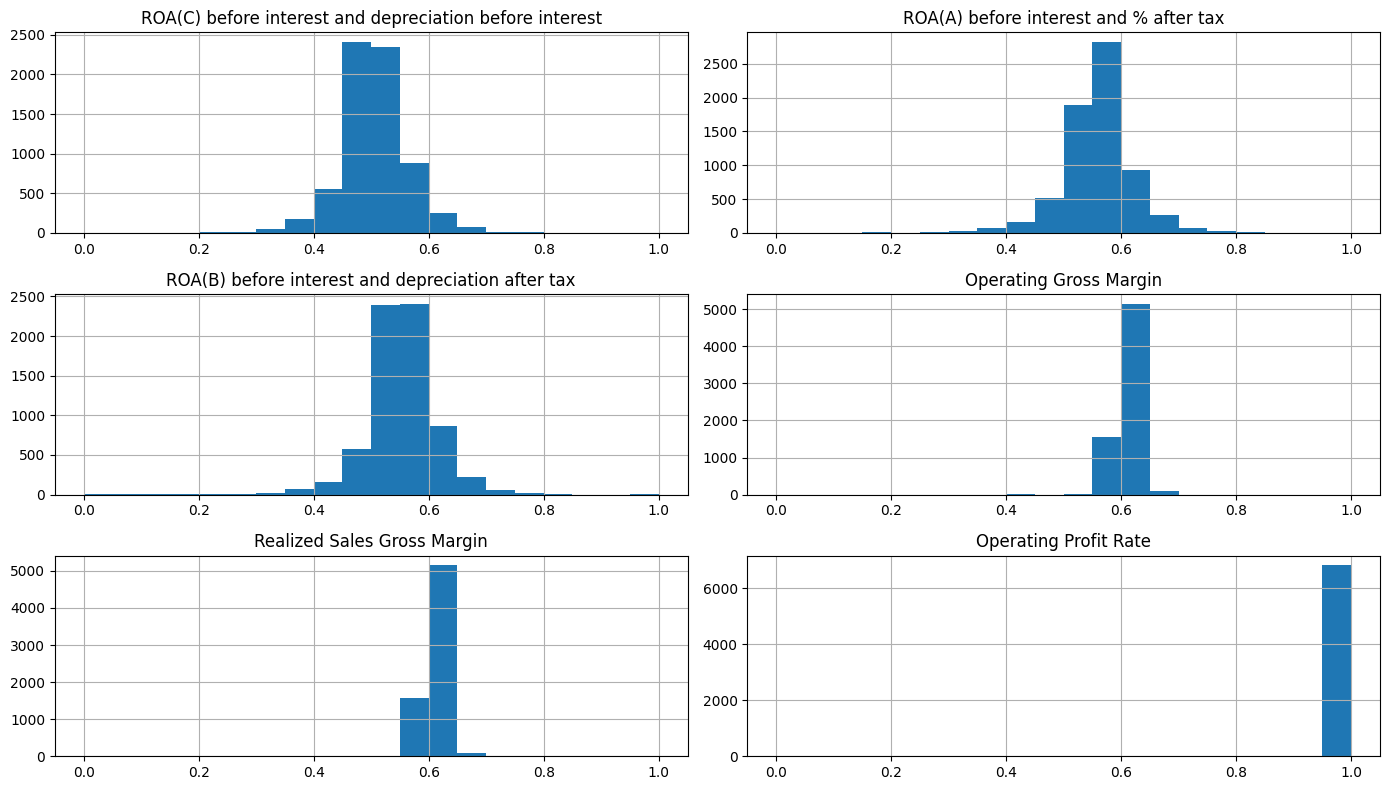

In [50]:
estatisticas_descritivas = df.describe()

for inicio in range(0, len(estatisticas_descritivas.columns), 12):
    display(estatisticas_descritivas.iloc[:, inicio:inicio + 12])

colunas_para_histograma = df.drop(columns=[coluna_alvo]).columns[:6]
df[colunas_para_histograma].hist(figsize=(14, 8), bins=20)
plt.tight_layout()
plt.show()

## Etapa 6: Verificacao de valores nulos

Nesta etapa, vamos identificar a quantidade e o percentual de valores nulos por coluna.

In [51]:
quantidade_nulos = df.isnull().sum()
percentual_nulos = (quantidade_nulos / len(df)) * 100

resumo_nulos = pd.DataFrame({
    'quantidade_nulos': quantidade_nulos,
    'percentual_nulos': percentual_nulos
})

resumo_nulos = resumo_nulos[resumo_nulos['quantidade_nulos'] > 0]
resumo_nulos = resumo_nulos.sort_values(by='quantidade_nulos', ascending=False)

display(resumo_nulos)

,quantidade_nulos,percentual_nulos


## Etapa 7: Distribuicao do target

Nesta etapa, vamos visualizar a contagem das classes da variavel alvo e sua distribuicao em um grafico simples.

,quantidade
Bankrupt?,
0,6599
1,220


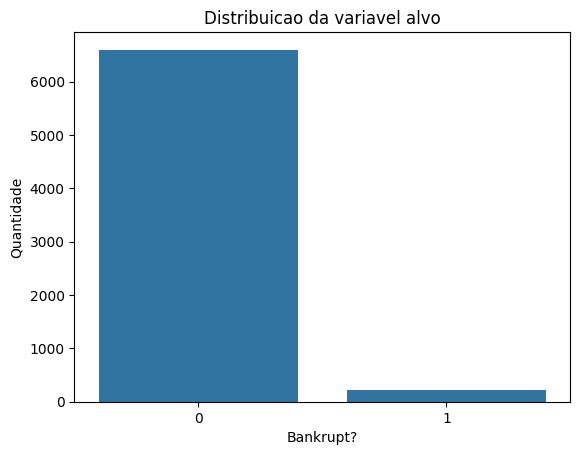

In [52]:
distribuicao_target = df[coluna_alvo].value_counts().sort_index().to_frame(name='quantidade')
display(distribuicao_target)

sns.countplot(data=df, x=coluna_alvo)
plt.title('Distribuicao da variavel alvo')
plt.xlabel(coluna_alvo)
plt.ylabel('Quantidade')
plt.show()

## Etapa 8: Visualizacao simples com boxplot

Nesta etapa, vamos observar a dispersao e possiveis outliers em variaveis numericas, com opcao de comparacao visual em escala padronizada.

In [53]:
from sklearn.preprocessing import StandardScaler

def gerar_boxplot(coluna_inicial=0, coluna_final=6, padronizar=False, y_inicial=None, y_final=None):
    colunas_numericas = df.drop(columns=[coluna_alvo]).select_dtypes(include=['number']).columns
    colunas_selecionadas = colunas_numericas[coluna_inicial:coluna_final]

    dados_boxplot = df[colunas_selecionadas].copy()

    if padronizar:
        escalonador = StandardScaler()
        dados_boxplot = pd.DataFrame(
            escalonador.fit_transform(dados_boxplot),
            columns=colunas_selecionadas
        )

    return dados_boxplot, y_inicial, y_final

def gerar_tabela_outliers(coluna_inicial=0, coluna_final=20):
    colunas_numericas = df.drop(columns=[coluna_alvo]).select_dtypes(include=['number']).columns
    colunas_selecionadas = colunas_numericas[coluna_inicial:coluna_final]
    dados_selecionados = df[colunas_selecionadas]

    resumo_outliers = []

    for coluna in colunas_selecionadas:
        q1 = dados_selecionados[coluna].quantile(0.25)
        q3 = dados_selecionados[coluna].quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        quantidade_outliers = ((dados_selecionados[coluna] < limite_inferior) | (dados_selecionados[coluna] > limite_superior)).sum()
        percentual_outliers = (quantidade_outliers / len(df)) * 100

        resumo_outliers.append({
            'coluna': coluna,
            'quantidade_outliers': quantidade_outliers,
            'percentual_outliers': percentual_outliers
        })

    return pd.DataFrame(resumo_outliers).sort_values(by='percentual_outliers', ascending=False)



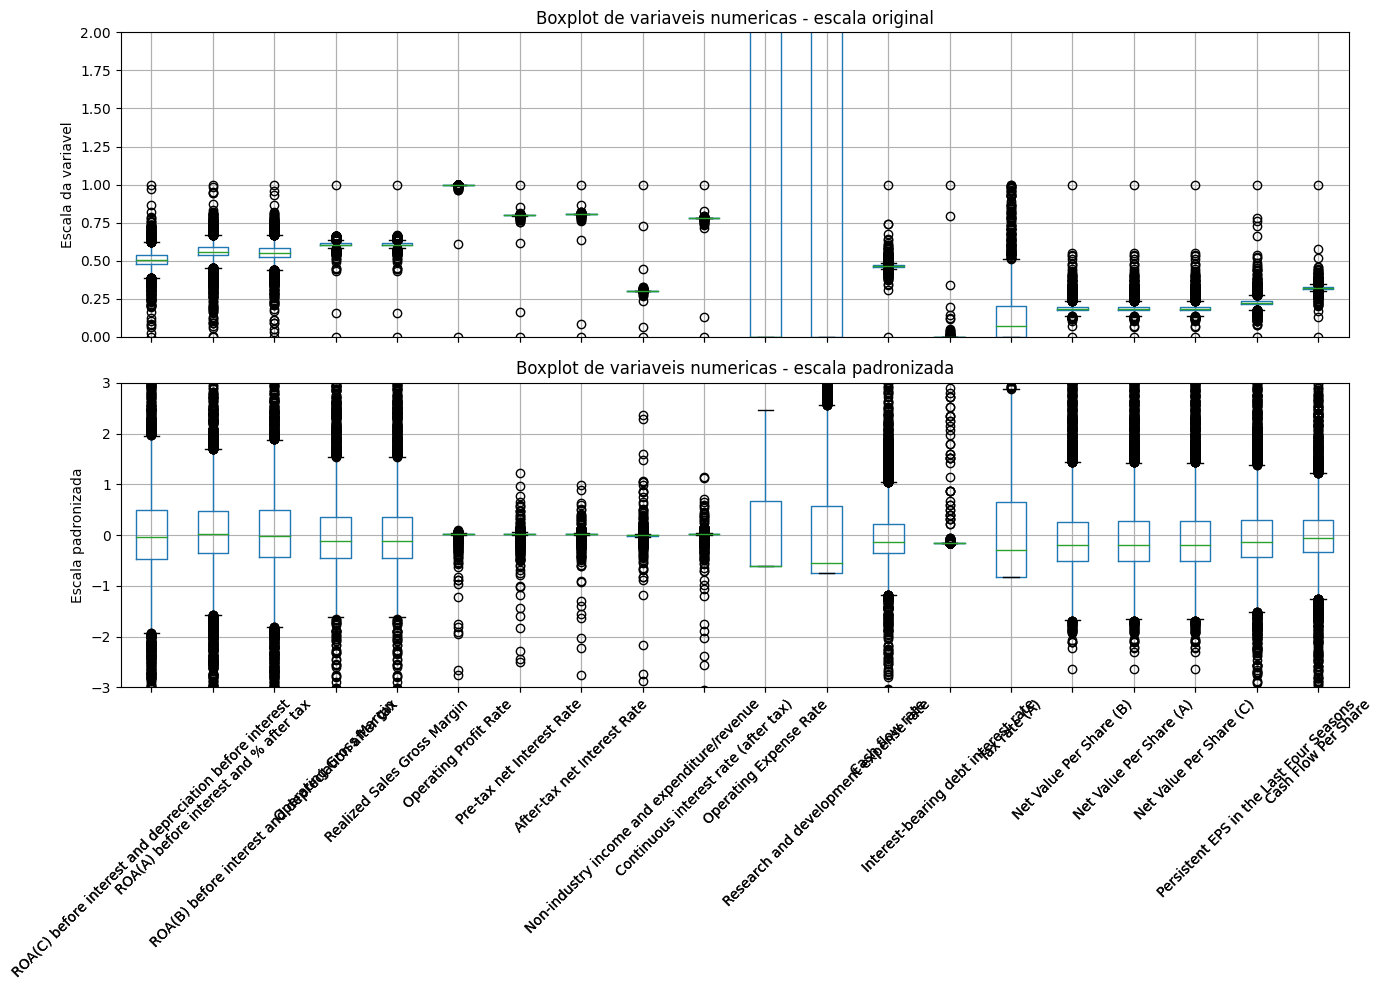

,coluna,quantidade_outliers,percentual_outliers
8,Non-industry income and expenditure/revenue,1094,16.0434
7,After-tax net Interest Rate,867,12.7145
9,Continuous interest rate (after tax),806,11.8199
6,Pre-tax net Interest Rate,773,11.3360
5,Operating Profit Rate,716,10.5001
12,Cash flow rate,576,8.4470
1,ROA(A) before interest and % after tax,561,8.2270
19,Cash Flow Per Share,532,7.8017
18,Persistent EPS in the Last Four Seasons,508,7.4498
17,Net Value Per Share (C),465,6.8192


In [54]:
coluna_inicial = 0
coluna_final = 20

y_inicial_original = 0
y_final_original = 2
y_inicial_padronizado = -3
y_final_padronizado = 3

dados_boxplot_original, _, _ = gerar_boxplot(
    coluna_inicial=coluna_inicial,
    coluna_final=coluna_final,
    padronizar=False,
    y_inicial=y_inicial_original,
    y_final=y_final_original
)

dados_boxplot_padronizado, _, _ = gerar_boxplot(
    coluna_inicial=coluna_inicial,
    coluna_final=coluna_final,
    padronizar=True,
    y_inicial=y_inicial_padronizado,
    y_final=y_final_padronizado
)

figura, eixos = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

dados_boxplot_original.boxplot(ax=eixos[0])
eixos[0].set_title('Boxplot de variaveis numericas - escala original')
eixos[0].set_ylabel('Escala da variavel')
eixos[0].set_ylim(y_inicial_original, y_final_original)

dados_boxplot_padronizado.boxplot(ax=eixos[1])
eixos[1].set_title('Boxplot de variaveis numericas - escala padronizada')
eixos[1].set_ylabel('Escala padronizada')
eixos[1].set_ylim(y_inicial_padronizado, y_final_padronizado)
eixos[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(gerar_tabela_outliers(coluna_inicial=coluna_inicial, coluna_final=coluna_final))